# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [1]:
#17 marketing campaigns
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score,
                              confusion_matrix, ConfusionMatrixDisplay, classification_report)

sns.set_style('whitegrid')

### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('data/bank-additional-full.csv', sep = ';')

 

In [4]:
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
print(df.info())
print("\nMissing/'unknown' values by column:")
cat_cols=df.select_dtypes(include='object').columns.tolist()
cat_cols.remove('y')
for c in cat_cols:
    cnt=(df[c]=='unknown').sum()
    if cnt>0:
        print(f"{c}: {cnt} ({cnt/len(df):.1%})")
        print("pdays==999(never contacted):",(df['pdays']==999).mean())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [7]:
df['y'].value_counts(normalize=True)

y
no     0.887346
yes    0.112654
Name: proportion, dtype: float64

**Business Objective**

The goal is to help the bank identify customers who are more likely to subscribe to a term deposit before making future marketing calls. A useful model should improve campaign efficiency by prioritizing likely subscribers while reducing unnecessary calls to customers who are unlikely to respond.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [8]:
# Use only the bank client information features requested in Problem 5.
numeric_features = ['age']
categorical_features = ['job', 'marital', 'education', 'default', 'housing', 'loan']

X = df[numeric_features + categorical_features].copy()
y = (df['y'] == 'yes').astype(int)

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

The bank client features contain one numeric variable (`age`) and six categorical variables. I standardize `age` so distance-based models such as KNN and SVM are not dominated by scale, and one-hot encode the categorical columns so all four classifiers can use them.

In [9]:
X.head()

,age,job,marital,education,default,housing,loan
0,56,housemaid,married,basic.4y,no,no,no
1,57,services,married,high.school,unknown,no,no
2,37,services,married,high.school,no,yes,no
3,40,admin.,married,basic.6y,no,no,no
4,56,services,married,high.school,no,no,yes


### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

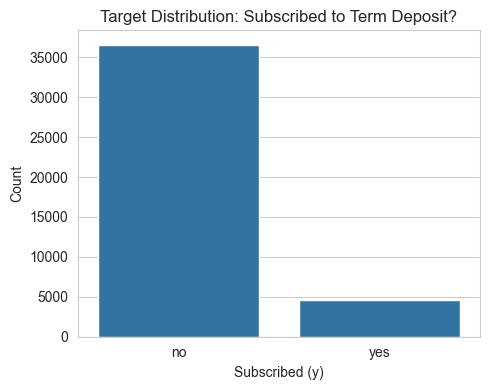

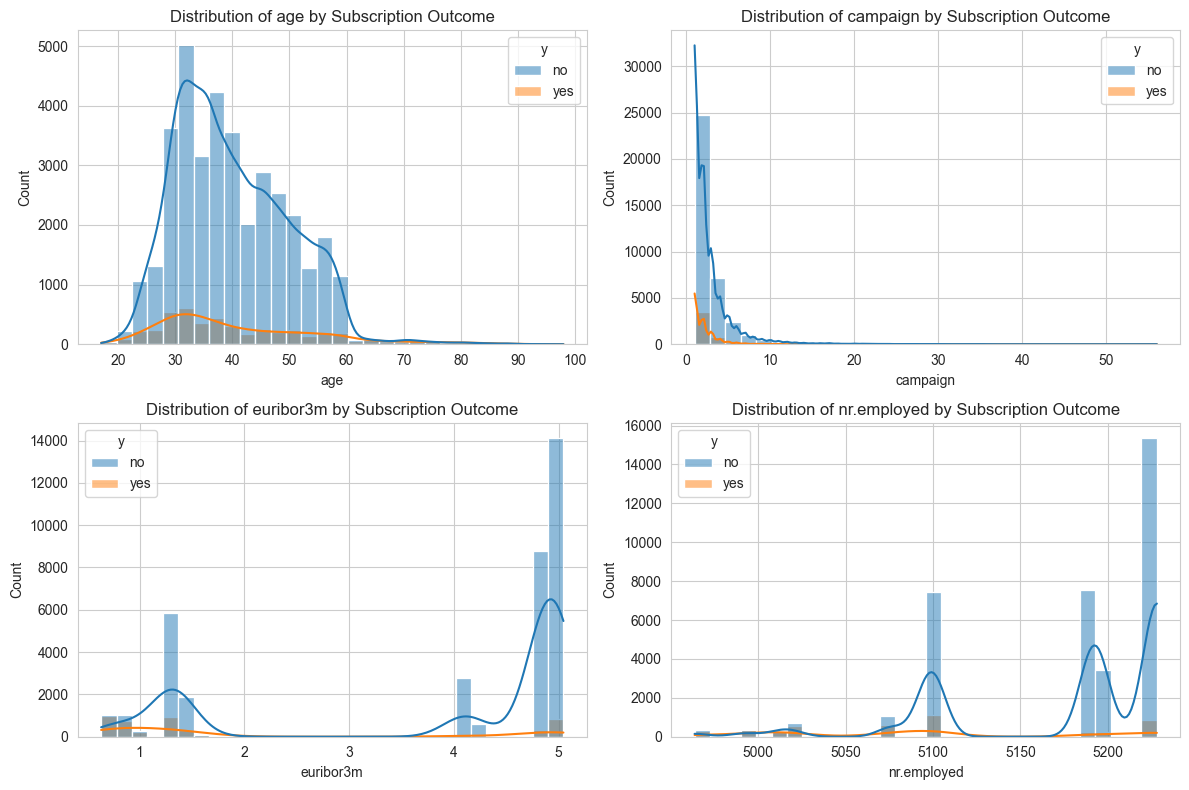

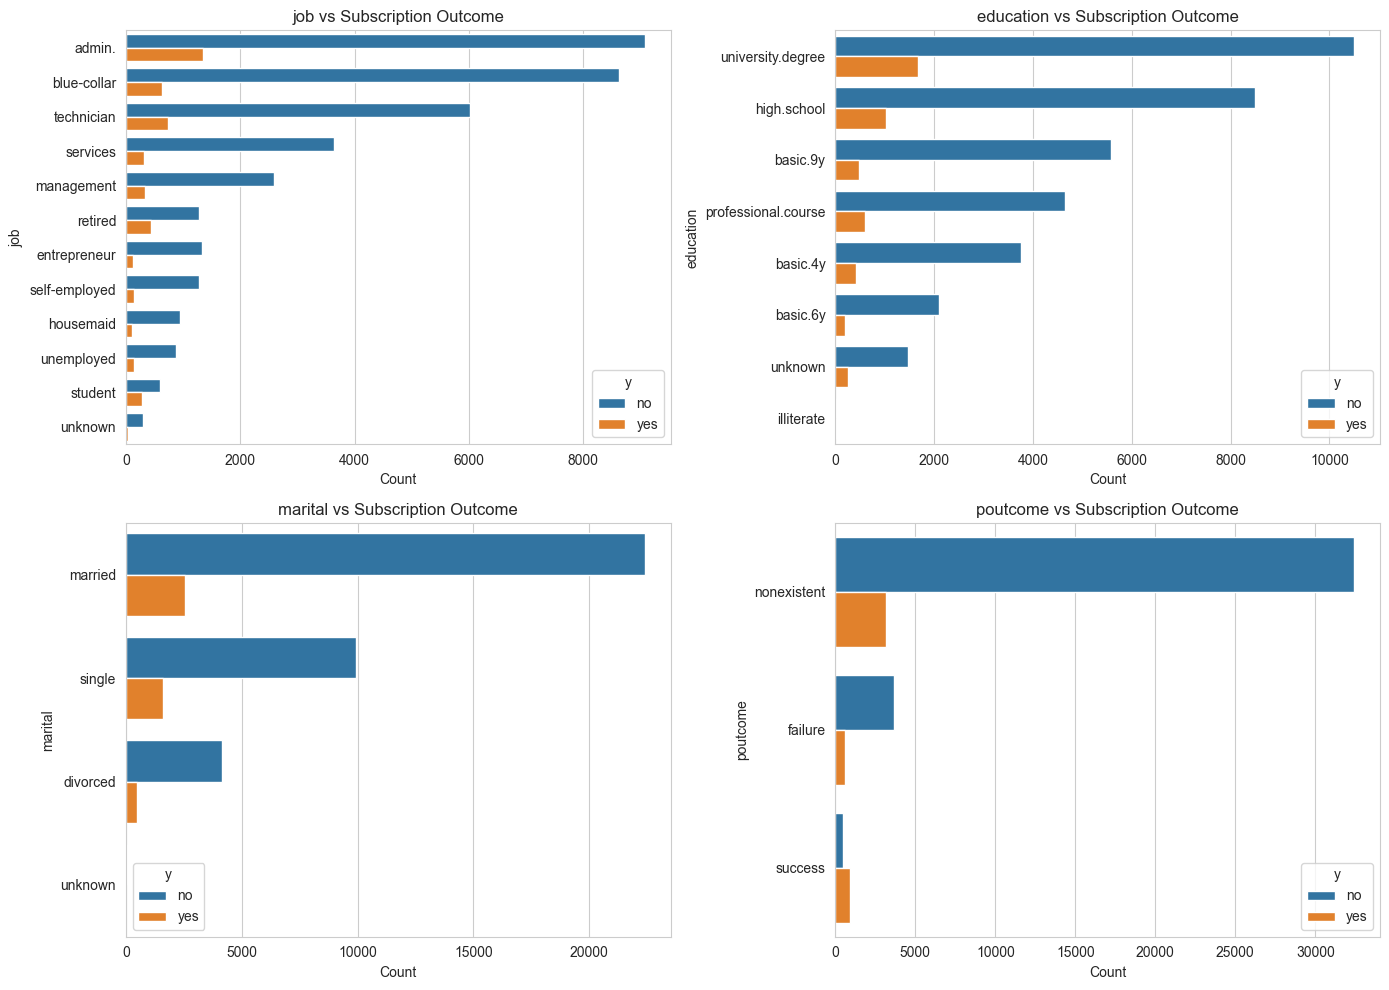

In [11]:
# Target class balance
fig, ax = plt.subplots(figsize=(5,4))
sns.countplot(x=df['y'], ax=ax)
ax.set_title('Target Distribution: Subscribed to Term Deposit?')
ax.set_xlabel('Subscribed (y)')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

# Numeric feature distributions
fig, axes = plt.subplots(2, 2, figsize=(12,8))
for ax, col in zip(axes.flat, ['age', 'campaign', 'euribor3m', 'nr.employed']):
    sns.histplot(data=df, x=col, hue='y', kde=True, ax=ax, bins=30)
    ax.set_title(f'Distribution of {col} by Subscription Outcome')
plt.tight_layout()
plt.show()

# Categorical features vs target
fig, axes = plt.subplots(2, 2, figsize=(14,10))
for ax, col in zip(axes.flat, ['job', 'education', 'marital', 'poutcome']):
    order = df[col].value_counts().index
    sns.countplot(data=df, y=col, hue='y', order=order, ax=ax)
    ax.set_title(f'{col} vs Subscription Outcome')
    ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

The split uses stratification so the train and test sets keep approximately the same subscription rate as the original data.

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [12]:
baseline_accuracy= max(y_train.mean(), 1-y_train.mean())
print(f"Baseline accuracy (always predict majority class): {baseline_accuracy:.4f}")

Baseline accuracy (always predict majority class): 0.8873


The majority class is `no`, so a classifier that always predicts `no` is the baseline. Any useful model should beat this accuracy and should also be evaluated with minority-class metrics such as recall and F1.

In [13]:
y_train.value_counts(normalize=True)

y
0    0.887346
1    0.112654
Name: proportion, dtype: float64

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [14]:
pipe_lr=Pipeline([('preprocessor', preprocessor),
                  ('classifier', LogisticRegression(max_iter=1000))])
pipe_lr.fit(X_train, y_train)
train_acc = pipe_lr.score(X_train, y_train)
test_acc = pipe_lr.score(X_test, y_test)
print(f"Train accuracy: {train_acc:.4f}, Test accuracy: {test_acc:.4f}")




Train accuracy: 0.8873, Test accuracy: 0.8873


### Problem 9: Score the Model

What is the accuracy of your model?

The simple logistic regression model matches the majority-class baseline when limited to bank client information features. Its F1 score is 0 because it predicts the majority class and misses the subscribed customers, so accuracy alone is not enough for this imbalanced problem. I will compare models using accuracy, precision, recall, and F1 so the minority `yes` class is represented in the evaluation.

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

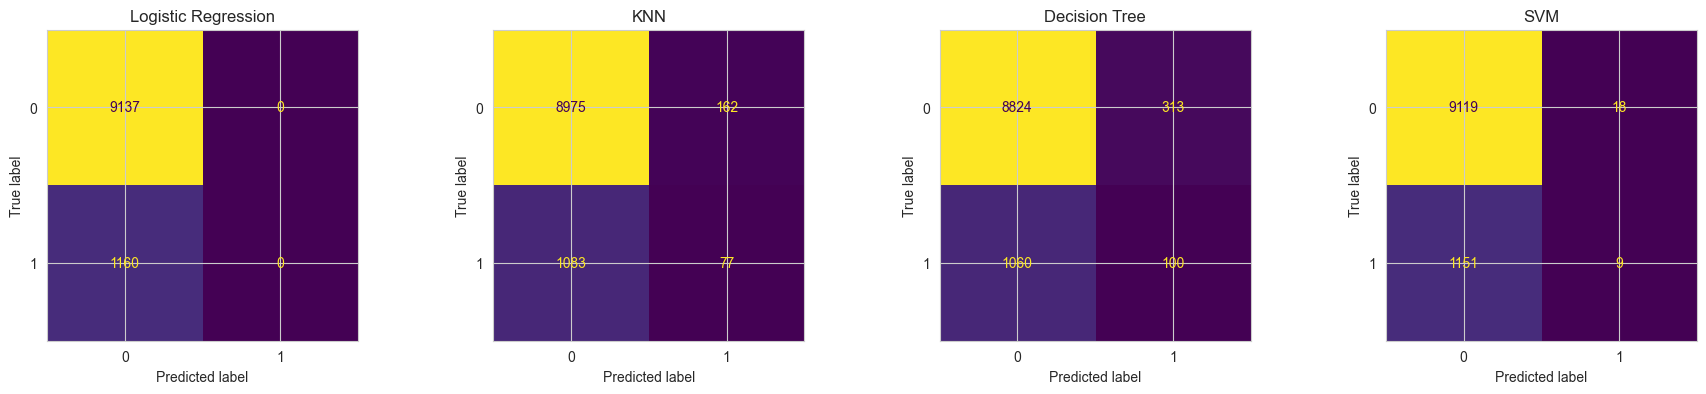

,Model,Train Time,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,0.028,0.8873,0.8873,0.0000,0.0000,0.0000
1,KNN,0.018,0.8919,0.8791,0.3222,0.0664,0.1101
2,Decision Tree,0.152,0.9178,0.8667,0.2421,0.0862,0.1271
3,SVM,20.678,0.8881,0.8865,0.3333,0.0078,0.0152


In [15]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'KNN': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'SVM': SVC()
}

results = []
fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, clf) in zip(axes, models.items()):
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
    t0 = time.time()
    pipe.fit(X_train, y_train)
    fit_time = time.time() - t0
    preds = pipe.predict(X_test)
    results.append([
        name,
        round(fit_time, 3),
        round(pipe.score(X_train, y_train), 4),
        round(pipe.score(X_test, y_test), 4),
        round(precision_score(y_test, preds, zero_division=0), 4),
        round(recall_score(y_test, preds, zero_division=0), 4),
        round(f1_score(y_test, preds, zero_division=0), 4)
    ])
    ConfusionMatrixDisplay.from_predictions(y_test, preds, ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.show()

results_df = pd.DataFrame(
    results,
    columns=['Model', 'Train Time', 'Train Accuracy', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']
)
results_df

In [16]:
results_df.sort_values('Test F1', ascending=False)

,Model,Train Time,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1
2,Decision Tree,0.152,0.9178,0.8667,0.2421,0.0862,0.1271
1,KNN,0.018,0.8919,0.8791,0.3222,0.0664,0.1101
3,SVM,20.678,0.8881,0.8865,0.3333,0.0078,0.0152
0,Logistic Regression,0.028,0.8873,0.8873,0.0000,0.0000,0.0000


The best model should not be selected from accuracy alone because the data is imbalanced. A model can look accurate by predicting mostly `no`, so F1 and recall provide a better view of how well the model finds likely subscribers.

### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [17]:
# Use the smaller file for faster grid searches while keeping the same feature engineering.
df_small = pd.read_csv('data/bank-additional.csv', sep=';')

X_small = df_small[numeric_features + categorical_features].copy()
y_small = (df_small['y'] == 'yes').astype(int)

Xs_train, Xs_test, ys_train, ys_test = train_test_split(
    X_small, y_small, test_size=0.25, random_state=42, stratify=y_small
)

param_grids = {
    'Logistic Regression': (
        LogisticRegression(max_iter=1000, class_weight='balanced'),
        {'classifier__C': [0.01, 0.1, 1, 10]}
    ),
    'KNN': (
        KNeighborsClassifier(),
        {'classifier__n_neighbors': [3, 5, 7, 9, 11, 15]}
    ),
    'Decision Tree': (
        DecisionTreeClassifier(random_state=42, class_weight='balanced'),
        {'classifier__max_depth': [2, 3, 4, 5, 7, 10, None]}
    ),
    'SVM': (
        SVC(class_weight='balanced'),
        {'classifier__C': [0.1, 1, 10], 'classifier__kernel': ['linear', 'rbf']}
    )
}

tuned_results = []
for name, (est, grid) in param_grids.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', est)])
    gs = GridSearchCV(pipe, grid, scoring='f1', cv=3, n_jobs=-1)
    gs.fit(Xs_train, ys_train)
    preds = gs.predict(Xs_test)
    tuned_results.append([
        name,
        gs.best_params_,
        round(accuracy_score(ys_test, preds), 4),
        round(precision_score(ys_test, preds, zero_division=0), 4),
        round(recall_score(ys_test, preds, zero_division=0), 4),
        round(f1_score(ys_test, preds, zero_division=0), 4)
    ])

tuned_df = pd.DataFrame(
    tuned_results,
    columns=['Model', 'Best Params', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1']
)
tuned_df.sort_values('Test F1', ascending=False)

,Model,Best Params,Test Accuracy,Test Precision,Test Recall,Test F1
0,Logistic Regression,{'classifier__C': 0.1},0.5942,0.1412,0.5310,0.2230
3,SVM,"{'classifier__C': 0.1, 'classifier__kernel': '...",0.5194,0.1270,0.5752,0.2080
2,Decision Tree,{'classifier__max_depth': 3},0.6553,0.1219,0.3451,0.1801
1,KNN,{'classifier__n_neighbors': 3},0.8573,0.1304,0.0531,0.0755


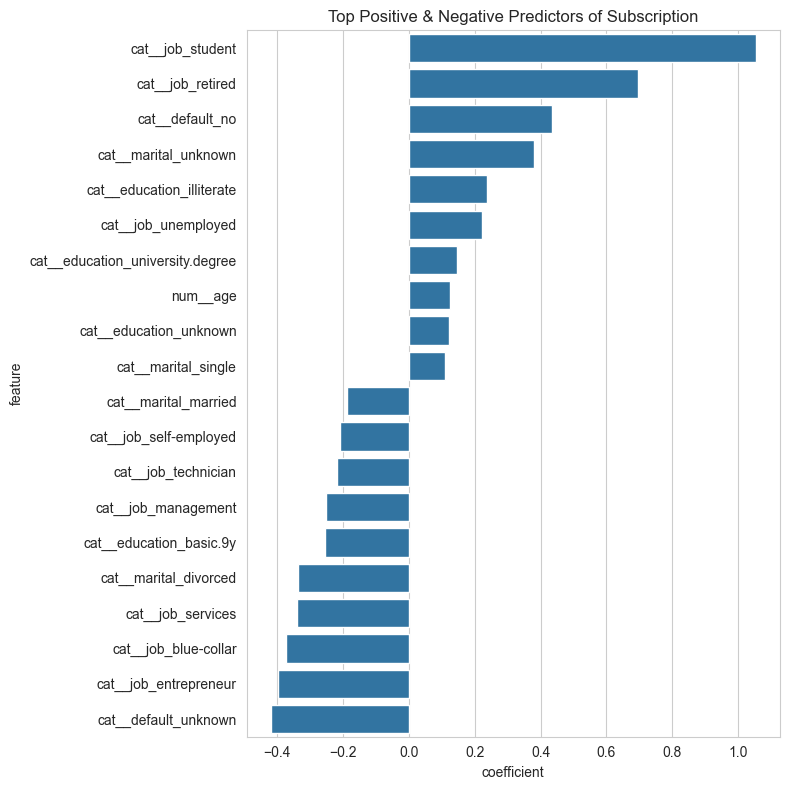

,feature,coefficient
9,cat__job_student,1.054009
6,cat__job_retired,0.695737
25,cat__default_no,0.434867
16,cat__marital_unknown,0.378604
21,cat__education_illiterate,0.235793
11,cat__job_unemployed,0.221939
23,cat__education_university.degree,0.147101
0,num__age,0.124604
24,cat__education_unknown,0.121577
15,cat__marital_single,0.108844


In [18]:
# Refit a balanced logistic regression model and inspect the strongest coefficients.
lr_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, class_weight='balanced', C=1))
])
lr_pipe.fit(X_train, y_train)

feature_names = lr_pipe.named_steps['preprocessor'].get_feature_names_out()
coefs = lr_pipe.named_steps['classifier'].coef_[0]
coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': coefs}) \
            .sort_values('coefficient', ascending=False)

fig, ax = plt.subplots(figsize=(8, 8))
top_bottom = pd.concat([coef_df.head(10), coef_df.tail(10)])
sns.barplot(data=top_bottom, x='coefficient', y='feature', ax=ax)
ax.set_title('Top Positive & Negative Predictors of Subscription')
plt.tight_layout()
plt.show()

coef_df.head(10)

In [19]:
best_tuned_model = tuned_df.sort_values('Test F1', ascending=False).iloc[0]
best_tuned_model

Model                Logistic Regression
Best Params       {'classifier__C': 0.1}
Test Accuracy                     0.5942
Test Precision                    0.1412
Test Recall                        0.531
Test F1                            0.223
Name: 0, dtype: object

For improvement, I tuned each classifier with F1 as the scoring metric and used `class_weight='balanced'` where supported. This better matches the business goal of finding likely subscribers in an imbalanced dataset, instead of simply maximizing the number of correct `no` predictions.

**Recommendation**

Use the tuned model with the strongest F1 score as the preferred candidate, then review its recall and precision tradeoff before deployment. If the bank wants to contact fewer customers, precision should be prioritized; if the bank wants to capture as many potential subscribers as possible, recall should be prioritized.

##### Questions